<a href="https://colab.research.google.com/github/UTD2026/Mixed_Dataset_Testing_STA/blob/main/TTL_ShiftPivot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribution-shift pivot — does the label-free router wake up OOD?

The one live thread after the in-distribution stress test. That run settled: no label-free signal
routes deployably in-distribution (best ≈0.69 vs `out_ce` 0.99), and combining signals buys nothing
on the full population — **except** the combiner on the *confident-wrong slice* reached **0.718**
at medicine 2B, the only supra-0.70 number anywhere.

**Sharpened hypothesis (the chase):** a base model that is genuinely out-of-distribution is often
*well-calibrated about being lost*. So the confident-wrong power the combiner showed in-distribution
may **hold or grow** under real shift — which is the one regime where a label-free router could
actually clear the bar. We hold the signal machinery *fixed* (same features, same fixed-span CMP,
same 5-fold OOF combiner) and vary only the distribution.

**Design.** Shift = a structurally different but **deterministically gradable** AdaptEval bench
(FinQA-numeric / gsm8k) vs the MCQA in-distribution domains. Gradability is non-negotiable: we need
real `base_ok`/`adapted_ok` to compute AUROC, so free-form judge-graded benches are excluded.

**Gate first (D9).** gsm8k/finance are exactly the benches likely to be in pretraining, so
contamination would fake the headroom. A proxy-free **verbatim-continuation probe** + **option-order
perturbation** screen the items *before* any routing number is trusted.

Reference to beat (in-distribution medicine 2B): combiner full **0.673**, confident-wrong **0.718**,
headroom **+0.224**, `out_ce` ceiling **0.99**.

## 0 · Knobs

In [1]:
REPO_URL   = "https://github.com/UTD2026/rishabh-tlm.git"
WORK       = "/content/tlm_shift"
LOCAL_REPO_ZIP = "/content/rishabh-tlm-main.zip"
GITHUB_TOKEN_ENV = "GITHUB_TOKEN"

MODEL      = "Qwen/Qwen3.5-2B"     # match the 2B in-dist reference where the 0.718 appeared
GEN_BATCH  = 8

# shift benches: structurally different from the MCQA in-dist domains, and DETERMINISTICALLY gradable
SHIFT = [
    {"tag":"finance",  "data":"data/AdaptEval/finance_finqa_random_5k.json", "n":1000},  # FinQA numeric
    {"tag":"gsm8k",    "data":"data/AdaptEval/gsm8k_random_5k.json",         "n":1000},  # grade-school math
]

# contamination gate (D9)
CONTAM_SPLIT_FRAC = 0.6      # feed this fraction of the question, ask model to continue
CONTAM_NGRAM      = 8        # n-gram for verbatim-overlap
CONTAM_FLAG_OV    = 0.5      # item flagged contaminated if >50% of its continuation n-grams are verbatim
CONTAM_ABORT_FRAC = 0.20     # abort D10 on a bench if >20% of items are flagged
PROXY_CORPUS      = None     # optional: path/URL to a pretraining-proxy text sample for external n-gram check

# in-distribution reference (from the stress test, medicine 2B)
IN_DIST_REF = {"combiner_full":0.673, "combiner_conf_wrong":0.718, "within_full":0.574,
               "out_ce":0.990, "headroom":0.224}
RUN_GPU = True
print({"model":MODEL, "shift":[s["tag"] for s in SHIFT], "ref":IN_DIST_REF})

{'model': 'Qwen/Qwen3.5-2B', 'shift': ['finance', 'gsm8k'], 'ref': {'combiner_full': 0.673, 'combiner_conf_wrong': 0.718, 'within_full': 0.574, 'out_ce': 0.99, 'headroom': 0.224}}


## 1 · Environment (Colab GPU, HF-only — no vLLM)

In [2]:
import os, sys, subprocess
from pathlib import Path
Path(WORK).mkdir(parents=True, exist_ok=True); os.chdir(WORK)
def pip(*a): print("pip",*a); subprocess.check_call([sys.executable,"-m","pip",*a])
if RUN_GPU:
    pip("install","-U","peft","accelerate","scipy","sympy","ninja","huggingface_hub")
    if "Qwen3.5" in MODEL:
        pip("install","-U","transformers[serving] @ git+https://github.com/huggingface/transformers.git@main")
    for pkg in ["torchaudio","torchvision","torchao"]:
        try: pip("uninstall","-y",pkg)
        except Exception as e: print("skip",pkg,e)
    for m in list(sys.modules):
        if m.startswith(("transformers","peft","torchaudio","torchvision","torchao")): del sys.modules[m]
import numpy as np, pandas as pd, matplotlib.pyplot as plt
print("stack ready")

pip install -U peft accelerate scipy sympy ninja huggingface_hub
pip install -U transformers[serving] @ git+https://github.com/huggingface/transformers.git@main
pip uninstall -y torchaudio
pip uninstall -y torchvision
pip uninstall -y torchao
stack ready


## 2 · Clone / upload the repo

In [4]:
import os, subprocess, shutil, zipfile
from pathlib import Path
repo_dir = Path(WORK)/"rishabh-tlm"
def _clone(url):
    tok=os.environ.get(GITHUB_TOKEN_ENV,"").strip()
    u=url.replace("https://",f"https://{tok}@",1) if (tok and url.startswith("https://github.com/")) else url
    return subprocess.run(["git","clone","--depth","1",u,str(repo_dir)],text=True,stdout=subprocess.PIPE,stderr=subprocess.PIPE)
def _extract(zp):
    zp=Path(zp).expanduser(); assert zp.exists(), f"no zip at {zp}"
    tmp=Path(WORK)/"_zip"; shutil.rmtree(tmp,ignore_errors=True); tmp.mkdir(parents=True)
    with zipfile.ZipFile(zp) as zf: zf.extractall(tmp)
    cand=tmp if (tmp/"cuda_ttl").exists() and (tmp/"results").exists() else \
         next((p for p in tmp.rglob("*") if p.is_dir() and (p/"cuda_ttl").exists() and (p/"results").exists()),None)
    assert cand is not None, "repo root not found in zip"
    shutil.rmtree(repo_dir,ignore_errors=True); shutil.move(str(cand),str(repo_dir))
if not repo_dir.exists():
    if _clone(REPO_URL).returncode!=0:
        print("clone failed (private repo / no token).")
        if Path(LOCAL_REPO_ZIP).exists(): _extract(LOCAL_REPO_ZIP)
        else:
            try:
                from google.colab import files
                print("upload the repo zip..."); up=files.upload()
                names=[n for n in up if n.lower().endswith(".zip")] or list(up)
                assert names, "no file uploaded"
                # files.upload() writes into cwd; find where it actually landed
                cand = Path(names[0])
                if not cand.exists(): cand = Path(os.getcwd())/names[0]
                if not cand.exists(): cand = Path("/content")/names[0]
                _extract(cand)
            except ImportError:
                _extract(Path(input("path to repo zip: ").strip().strip('"')))
os.chdir(repo_dir); REPO_DIR=Path.cwd()
assert (REPO_DIR/"cuda_ttl").exists(); print("repo:", REPO_DIR)

clone failed (private repo / no token).
upload the repo zip...


Saving rishabh-tlm-main (1).zip to rishabh-tlm-main (1) (1).zip
repo: /content/tlm_shift/rishabh-tlm


## 3 · Helpers — model I/O, grading, AUROC, fixed-span CMP, OOF combiner

All reused verbatim from the stress test so the *only* thing that changes vs in-distribution is the
data. CMP is the fixed version (CE over the base's exact greedy answer **token-ids** — no
decode/re-encode).

In [5]:
import torch, json, transformers
import torch.nn.functional as F
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
SCRIPTS=REPO_DIR/"cuda_ttl/ab_routing"; sys.path.insert(0,str(SCRIPTS))
import grading

def load_lm(path):
    tok=AutoTokenizer.from_pretrained(path, trust_remote_code=True)
    if tok.pad_token_id is None: tok.pad_token=tok.eos_token
    tok.padding_side="left"
    cfg=AutoConfig.from_pretrained(path, trust_remote_code=True)
    arch=(getattr(cfg,"architectures",None) or [""])[0]
    cls=getattr(transformers,arch,None) or AutoModelForCausalLM
    m=cls.from_pretrained(path, torch_dtype=torch.bfloat16, device_map="cuda").eval()
    return m, tok
def wrap(tok,q):
    msgs=[{"role":"user","content":q}]
    try: return tok.apply_chat_template(msgs,tokenize=False,add_generation_prompt=True,enable_thinking=False)
    except TypeError: return tok.apply_chat_template(msgs,tokenize=False,add_generation_prompt=True)
def qof(r): return (r.get("question") or r.get("instruction") or "").strip()
def goldof(r):
    for k in ("output","answer","answers"):
        if r.get(k) not in (None,""): return str(r[k]).strip()
    return ""

def auroc(y,s):
    y=np.asarray(y); s=np.asarray(s,float); m=~np.isnan(s); y,s=y[m],s[m]
    pos,neg=(y==1),(y==0)
    if pos.sum()==0 or neg.sum()==0: return float("nan")
    o=np.argsort(s); r=np.empty(len(s)); r[o]=np.arange(1,len(s)+1)
    return (r[pos].sum()-pos.sum()*(pos.sum()+1)/2)/(pos.sum()*neg.sum())

def _fit_logistic(X,y,l2=1.0,iters=800,lr=0.3):
    Xb=np.c_[np.ones(len(X)),X]; w=np.zeros(Xb.shape[1])
    for _ in range(iters):
        p=1/(1+np.exp(-np.clip(Xb@w,-30,30))); g=Xb.T@(p-y)/len(y); g[1:]+=l2*w[1:]/len(y); w-=lr*g
    return w
def _pred(w,X): return 1/(1+np.exp(-np.clip(np.c_[np.ones(len(X)),X]@w,-30,30)))
def oof_auroc(X,y,k=5,seed=0):
    n=len(y); idx=np.arange(n); np.random.RandomState(seed).shuffle(idx)
    folds=np.array_split(idx,k); oof=np.full(n,np.nan)
    for f in range(k):
        te=folds[f]; tr=np.concatenate([folds[j] for j in range(k) if j!=f])
        mu=X[tr].mean(0); sd=X[tr].std(0)+1e-9
        w=_fit_logistic((X[tr]-mu)/sd,y[tr].astype(float)); oof[te]=_pred(w,(X[te]-mu)/sd)
    return auroc(y,oof), oof
print("helpers ready")

helpers ready


## D9 · Contamination gate — must pass before any routing number is trusted

Two proxy-free screens (a third external one if `PROXY_CORPUS` is set):

**D9a — verbatim-continuation probe.** Feed the first `CONTAM_SPLIT_FRAC` of each item's text and let
the base model greedily continue; measure the fraction of `CONTAM_NGRAM`-grams in its continuation
that appear verbatim in the held-out true remainder. High overlap ⇒ the model has *seen this item* ⇒
memorised, not shifted. Needs only the model.

**D9c — option-order perturbation** (choice benches only). Re-label the answer options and regrade; a
large accuracy drop means the model keyed on option *position*, a memorisation smell. Numeric/math
benches skip this (no options to permute) and lean on D9a.

Output: a per-item `contaminated` flag and a bench-level verdict. Flagged items are **excluded** from
D10's AUROC so the headroom that survives is on genuinely-novel items.

In [6]:
def ngrams(toks,n): return set(tuple(toks[i:i+n]) for i in range(len(toks)-n+1)) if len(toks)>=n else set()

def d9_verbatim(recs, tok, model, split=CONTAM_SPLIT_FRAC, n=CONTAM_NGRAM):
    """fraction of continuation n-grams the model reproduces verbatim from the true remainder"""
    flags={}
    for s in range(0,len(recs),GEN_BATCH):
        ch=list(range(s,min(s+GEN_BATCH,len(recs)))); prompts=[]; tails=[]
        for i in ch:
            full=qof(recs[i]); w=full.split()
            cut=max(1,int(len(w)*split)); prompts.append(" ".join(w[:cut])); tails.append(w[cut:])
        enc=tok(prompts, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(model.device)
        with torch.inference_mode():
            o=model.generate(**enc, max_new_tokens=48, do_sample=False, pad_token_id=tok.pad_token_id)
        cont=tok.batch_decode(o[:,enc["input_ids"].shape[1]:], skip_special_tokens=True)
        for bi,i in enumerate(ch):
            gen=cont[bi].split(); true=tails[bi]
            g=ngrams(gen,n); t=ngrams(true,n)
            flags[i]= (len(g & t)/max(1,len(g))) if g else 0.0
    return flags

def d9_perturb(recs, tok, model, at):
    """choice-only: shuffle option labels A/B/C/D, regrade; return base_ok and base_ok_perturbed"""
    import re, random
    if at!="choice": return None
    def relabel(q):
        # find "A. ... B. ... C. ... D. ..." blocks and rotate labels A->B->C->D->A
        rot={"A":"B","B":"C","C":"D","D":"A"}
        return re.sub(r'\b([ABCD])\.', lambda m: rot[m.group(1)]+".", q), rot
    ok0={}; okP={}
    for tagP,transform in [("orig",lambda q:(q,None)),("perm",relabel)]:
        for s in range(0,len(recs),GEN_BATCH):
            ch=list(range(s,min(s+GEN_BATCH,len(recs)))); qs=[]; rots=[]
            for i in ch:
                q,rot=transform(qof(recs[i])); qs.append(q); rots.append(rot)
            enc=tok([wrap(tok,x) for x in qs], return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)
            with torch.inference_mode():
                o=model.generate(**enc, max_new_tokens=16, do_sample=False, pad_token_id=tok.pad_token_id)
            dec=tok.batch_decode(o[:,enc["input_ids"].shape[1]:], skip_special_tokens=True)
            for bi,i in enumerate(ch):
                pred=grading.extract(dec[bi],at).value; gold=goldof(recs[i])
                if tagP=="orig": ok0[i]=grading.is_correct(pred,gold,at)
                else:
                    # perturbed: the gold letter also rotates
                    g2=rots[bi].get(gold,gold) if rots[bi] else gold
                    okP[i]=grading.is_correct(pred,g2,at)
    return ok0, okP

CONTAM={}   # tag -> {"flags":{i:ov}, "keep":[idx], "frac":f, "verdict":str}
if RUN_GPU:
    for spec in SHIFT:
        tag=spec["tag"]; recs=json.load(open(spec["data"]))[:spec["n"]]
        at=grading.detect_answer_type(tag) or "choice"
        bm,btok=load_lm(MODEL)
        flags=d9_verbatim(recs,btok,bm)
        pert=d9_perturb(recs,btok,bm,at)
        del bm; torch.cuda.empty_cache()
        contaminated={i for i,ov in flags.items() if ov>CONTAM_FLAG_OV}
        frac=len(contaminated)/len(recs)
        keep=[i for i in range(len(recs)) if i not in contaminated]
        note=f"verbatim>{CONTAM_FLAG_OV}: {frac:.1%}"
        if pert:
            ok0,okP=pert; drop=np.mean([ok0[i] for i in ok0])-np.mean([okP[i] for i in okP])
            note+=f" | option-perturb acc drop {drop:+.3f}"
        verdict=("ABORT (memorised)" if frac>CONTAM_ABORT_FRAC else "PROCEED (exclude flagged)")
        CONTAM[tag]={"flags":flags,"keep":keep,"frac":frac,"verdict":verdict,"note":note}
        print(f"[{tag}] {note} -> {verdict}  (keep {len(keep)}/{len(recs)})")
else:
    print("RUN_GPU=False — contamination gate needs the model; set RUN_GPU=True on a GPU box.")

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

[finance] verbatim>0.5: 1.0% -> PROCEED (exclude flagged)  (keep 990/1000)


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

[gsm8k] verbatim>0.5: 0.0% -> PROCEED (exclude flagged)  (keep 1000/1000)


## D10 · The pivot — run the fixed machinery on the (screened) shift bench

For each bench that PROCEEDs: build `out_ce` features (repo pool builder) → top-5% specialist
(`ab_train_ttl --no-merge`) → base/adapted greedy (graded) → within-model confidence + fixed-span CMP
→ 5-fold OOF combiner. Report headroom and the combiner's **full** and **confident-wrong** AUROC on
the *clean* items, side by side with the in-distribution reference. The one number that matters:
does confident-wrong meet or beat **0.718**?

In [11]:
import re
def gold_for(recs, i, at, tag):
    raw = goldof(recs[i])
    if tag == "gsm8k":
        m = re.search(r'####\s*(.+)', raw)          # gsm8k gold = text after ####
        raw = m.group(1).strip() if m else raw
    # normalize gold through the SAME extractor used on predictions
    ex = grading.extract(raw, at)
    return ex.value if ex.value is not None else raw.strip()

# sanity BEFORE the full rerun: grade base preds you already have in memory
for tag, recs_key in [("finance","finance"),("gsm8k","gsm8k")]:
    spec = next(s for s in SHIFT if s["tag"]==tag)
    recs = json.load(open(spec["data"]))[:spec["n"]]
    at = grading.detect_answer_type(tag)
    # bpred is gone after the loop; regenerate a quick 50-item base sample to test grading only
    bm, btok = load_lm(MODEL)
    idxs = list(range(50))
    bpred,_,_ = hf_greedy(bm, btok, recs, idxs)
    del bm; torch.cuda.empty_cache()
    acc = np.mean([grading.is_correct(grading.extract(bpred[i],at).value, gold_for(recs,i,at,tag), at) for i in idxs])
    print(f"[{tag}] base acc on 50 items with fixed grading: {acc:.3f}")
    print(f"   sample gold raw: {goldof(recs,0) if False else goldof(recs[0])!r}")
    print(f"   sample pred: {bpred[0][:80]!r}")

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

[finance] base acc on 50 items with fixed grading: 0.000
   sample gold raw: '231.9%'
   sample pred: '100.0\n'


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

[gsm8k] base acc on 50 items with fixed grading: 0.020
   sample gold raw: 'The total cost of the entrees is 4 * $20 = $<<4*20=80>>80.\nThe total cost of the dinner is $80 + $10 = $<<80+10=90>>90.\nThe tip is $90 * 0.20 = $<<90*0.20=18>>18\nThe total cost with tip is $90 + $18 = $<<90+18=108>>108\n#### 108'
   sample pred: "To find the total amount of money Stefan's family spends, we need to calculate t"


In [13]:
from peft import PeftModel
from tqdm.auto import tqdm
import re, time

def hf_greedy(model, tok, recs, idxs, max_new=64, want_conf=False, desc="gen"):
    preds={}; conf={}; ansids={}
    side=tok.padding_side; tok.padding_side="left"
    for s in tqdm(range(0,len(idxs),GEN_BATCH), desc=desc, leave=False):
        ch=idxs[s:s+GEN_BATCH]
        enc=tok([wrap(tok,qof(recs[i])) for i in ch], return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)
        w=enc["input_ids"].shape[1]
        with torch.inference_mode():
            o=model.generate(**enc, max_new_tokens=max_new, do_sample=False,
                             output_scores=want_conf, return_dict_in_generate=want_conf, pad_token_id=tok.pad_token_id)
        seq=(o.sequences[:,w:] if want_conf else o[:,w:])
        if want_conf:
            P=torch.stack([torch.softmax(sc.float(),-1) for sc in o.scores],1)
            chosen=P.gather(-1,seq.unsqueeze(-1)).squeeze(-1)
        mask=(seq!=tok.pad_token_id)
        dec=tok.batch_decode(seq, skip_special_tokens=True)
        for bi,i in enumerate(ch):
            mk=mask[bi]; preds[i]=dec[bi]; ansids[i]=seq[bi][mk].tolist()
            if want_conf: conf[i]=float(chosen[bi][mk].mean()) if mk.any() else 0.0
    tok.padding_side=side
    return preds, conf, ansids

def cmp_scores(model, tok, recs, ansids, desc="cmp"):
    side=tok.padding_side; tok.padding_side="right"
    pad=tok.pad_token_id or tok.eos_token_id; out={}
    items=list(ansids.keys())
    for s in tqdm(range(0,len(items),GEN_BATCH), desc=desc, leave=False):
        ch=items[s:s+GEN_BATCH]; seqs=[]; spans=[]
        for i in ch:
            pids=tok.encode(wrap(tok,qof(recs[i])), add_special_tokens=False)
            aids=ansids[i] or [pad]; seqs.append(pids+aids); spans.append((len(pids),len(aids)))
        ml=max(len(x) for x in seqs)
        inp=torch.tensor([x+[pad]*(ml-len(x)) for x in seqs],device=model.device)
        att=torch.tensor([[1]*len(x)+[0]*(ml-len(x)) for x in seqs],device=model.device)
        with torch.inference_mode(): lg=model(input_ids=inp,attention_mask=att).logits.float()
        for bi,i in enumerate(ch):
            pl,al=spans[bi]
            out[i]=float(F.cross_entropy(lg[bi][pl-1:pl+al-1], inp[bi][pl:pl+al])) if al>0 else 0.0
    tok.padding_side=side; return out

def load_adapter(base_model_path, adapter_dir):
    base, tok = load_lm(base_model_path)
    m = PeftModel.from_pretrained(base, str(adapter_dir)).eval()
    return m, tok

def gold_for(recs, i, at, tag):
    raw = goldof(recs[i])
    if tag == "gsm8k":
        m = re.search(r'####\s*(.+)', raw)
        raw = m.group(1).strip() if m else raw
    ex = grading.extract(raw, at)
    return ex.value if ex.value is not None else raw.strip()

def is_correct_flex(pred_val, gold_val, at):
    if grading.is_correct(pred_val, gold_val, at): return True
    if at == "numeric" and pred_val is not None:
        try:
            pv=float(re.sub(r'[%,$\s]','',str(pred_val))); gv=float(re.sub(r'[%,$\s]','',str(gold_val)))
            for scale in (1.0, 100.0, 0.01):
                if abs(pv - gv*scale) <= 1e-3*max(1.0,abs(gv*scale)): return True
        except Exception: pass
    return False

def sh(cmd, log, label):
    """stream a subprocess with a heartbeat so it never looks frozen"""
    print(f"    ├─ {label}: {' '.join(map(str,cmd[-4:]))}", flush=True)
    t0=time.time(); nlines=0
    with open(log,"w") as f:
        p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
        for ln in p.stdout:
            f.write(ln); nlines+=1
            if nlines % 20 == 0:
                print(f"    │   …{label} running {time.time()-t0:0.0f}s ({nlines} log lines)", flush=True)
        if p.wait()!=0: raise RuntimeError(f"failed {cmd} (see {log})")
    print(f"    └─ {label} done in {time.time()-t0:0.0f}s", flush=True)

MAXNEW_BY_TYPE = {"numeric":256, "math":256, "choice":8}

PIVOT=[] if "PIVOT" not in dir() else PIVOT           # keep completed benches across interrupts/reruns
_done={r["bench"] for r in PIVOT}

if RUN_GPU:
    for spec in SHIFT:
        tag=spec["tag"]
        if tag in _done:
            print(f"[{tag}] already in PIVOT — skipping (clear PIVOT to redo)."); continue
        if tag not in CONTAM or CONTAM[tag]["verdict"].startswith("ABORT"):
            print(f"[{tag}] skipped (contamination verdict).") ; continue
        print(f"\n=== [{tag}] ({SHIFT.index(spec)+1}/{len(SHIFT)}) ===", flush=True)
        recs=json.load(open(spec["data"]))[:spec["n"]]; at=grading.detect_answer_type(tag) or "choice"
        MAXNEW=MAXNEW_BY_TYPE.get(at, 64)
        keep=CONTAM[tag]["keep"]; W=Path(WORK)/"shift"/tag; W.mkdir(parents=True,exist_ok=True)
        print(f"  n={len(recs)}  answer_type={at}  max_new={MAXNEW}  keep={len(keep)}", flush=True)

        if not (W/"pool"/"features.jsonl").exists():
            print("  [1/5] building out_ce features (pool)…", flush=True)
            sh([sys.executable,str(SCRIPTS/"ab_build_pool.py"),"--model",MODEL,"--data",spec["data"],
                "--dataset",tag,"--max-samples",str(spec["n"]),"--out-dir",str(W/"pool")], W/"pool.log","pool")
        else: print("  [1/5] features cached ✓", flush=True)

        feats=[json.loads(l) for l in open(W/"pool"/"features.jsonl")]; oce={f["idx"]:f["out_ce"] for f in feats}
        cap=max(1,int(0.05*len(feats))); sel=sorted(oce,key=lambda i:-oce[i])[:cap]
        json.dump({"selected":[{"idx":int(i),"weight":1.0} for i in sel]}, open(W/"sel.json","w"))

        if not (W/"adapter"/"adapter_model.safetensors").exists():
            print(f"  [2/5] training top-CE specialist ({cap} items)…", flush=True)
            sh([sys.executable,str(SCRIPTS/"ab_train_ttl.py"),"--model",MODEL,"--data",spec["data"],
                "--selection-file",str(W/"sel.json"),"--max-samples",str(spec["n"]),
                "--output-dir",str(W/"adapter"),"--no-merge"], W/"train.log","train")
        else: print("  [2/5] adapter cached ✓", flush=True)

        allidx=list(range(len(recs)))
        print("  [3/5] base generation + confidence…", flush=True)
        bm,btok=load_lm(MODEL)
        bpred,bconf,bansids=hf_greedy(bm,btok,recs,allidx,max_new=MAXNEW,want_conf=True,desc=f"{tag} base")
        del bm; torch.cuda.empty_cache()

        print("  [4/5] adapted generation + CMP…", flush=True)
        am,atok=load_adapter(MODEL, W/"adapter")
        nz=sum(1 for n,p in am.named_parameters() if "lora_B" in n and p.abs().max()>0); assert nz>0,"adapter no-op: 0 lora_B loaded"
        apred,_,_=hf_greedy(am,atok,recs,allidx,max_new=MAXNEW,desc=f"{tag} adapted")
        cmp=cmp_scores(am,atok,recs,bansids,desc=f"{tag} cmp")
        del am; torch.cuda.empty_cache()

        print("  [5/5] grading + AUROC…", flush=True)
        base_ok={i:is_correct_flex(grading.extract(bpred[i],at).value, gold_for(recs,i,at,tag), at) for i in allidx}
        adp_ok ={i:is_correct_flex(grading.extract(apred[i],at).value, gold_for(recs,i,at,tag), at) for i in allidx}
        qce={f["idx"]:f.get("q_ce",np.nan) for f in feats}
        rows=[dict(idx=i, base_ok=bool(base_ok[i]), adapted_ok=bool(adp_ok[i]), within=bconf.get(i,np.nan),
                   cmp=cmp.get(i,np.nan), q_ce=qce.get(i,np.nan), out_ce=oce.get(i,np.nan)) for i in keep]
        D=pd.DataFrame(rows)
        nz_cmp=(D["cmp"].fillna(0)>0).mean()
        trunc=np.mean([not bpred[i].strip().endswith((".","!","?")) and len(bansids[i])>=MAXNEW-1 for i in keep])
        print(f"  [{tag}] base_acc={D.base_ok.mean():.3f}  adapt_acc={D.adapted_ok.mean():.3f}  CMP_nonzero={nz_cmp:.2f}  hit_maxlen~{trunc:.2f}  n={len(D)}", flush=True)
        if D.base_ok.mean() < 0.05:
            print(f"  [{tag}] WARNING base_acc<5% — dead-OOD or a grading/length miss; inspect 3 pred/gold pairs before trusting headroom.", flush=True)
        if trunc > 0.10:
            print(f"  [{tag}] WARNING {trunc:.0%} of preds hit max_new — bump MAXNEW_BY_TYPE and rerun this bench.", flush=True)

        b=D.base_ok.mean(); a=D.adapted_ok.mean(); orc=(D.base_ok|D.adapted_ok).mean(); head=orc-b
        y=(~D.base_ok).astype(int).values
        use=[c for c in ["within","cmp","q_ce"] if not D[c].isna().all()]
        if len(use)>=2 and 20<y.sum()<len(y)-20:
            X=D[use].astype(float).copy()
            for c in use: X[c]=X[c].fillna(X[c].mean())
            comb_full,oof=oof_auroc(X.values,y)
            ca=D["within"].astype(float).values; hi=ca>=np.nanmedian(ca)
            comb_cw=auroc(y[hi],oof[hi]) if hi.sum()>20 else np.nan
        else:
            comb_full=comb_cw=np.nan
            print(f"  [{tag}] combiner skipped (usable signals={use}, base-wrong={y.sum()}/{len(y)} — label too skewed)", flush=True)
        within_full=max(auroc(y,-D["within"].values.astype(float)), auroc(y,D["within"].values.astype(float))) if not D["within"].isna().all() else np.nan
        out_ce_full=max(auroc(y,D["out_ce"].values.astype(float)), auroc(y,-D["out_ce"].values.astype(float))) if not D["out_ce"].isna().all() else np.nan
        PIVOT.append(dict(bench=tag, n_clean=len(D), base=round(b,3), adapt_all=round(a,3), oracle=round(orc,3),
                          headroom=round(head,3),
                          within_full=round(within_full,3) if not np.isnan(within_full) else np.nan,
                          combiner_full=round(comb_full,3) if not np.isnan(comb_full) else np.nan,
                          combiner_conf_wrong=round(comb_cw,3) if not np.isnan(comb_cw) else np.nan,
                          out_ce_ceiling=round(out_ce_full,3) if not np.isnan(out_ce_full) else np.nan))
        print("  [%s] headroom=%.3f  combiner_full=%s  combiner_conf_wrong=%s  (ref cw=0.718)"%(
              tag,head,PIVOT[-1]["combiner_full"],PIVOT[-1]["combiner_conf_wrong"]), flush=True)
    PIV=pd.DataFrame(PIVOT); display(PIV) if len(PIV) else print("no benches passed the gate")
else:
    print("RUN_GPU=False — D10 needs the model.")

[finance] already in PIVOT — skipping (clear PIVOT to redo).

=== [gsm8k] (2/2) ===
  n=1000  answer_type=numeric  max_new=256  keep=1000
  [1/5] features cached ✓
  [2/5] adapter cached ✓
  [3/5] base generation + confidence…


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

gsm8k base:   0%|          | 0/125 [00:00<?, ?it/s]

  [4/5] adapted generation + CMP…


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

gsm8k adapted:   0%|          | 0/125 [00:00<?, ?it/s]

gsm8k cmp:   0%|          | 0/125 [00:00<?, ?it/s]

  [5/5] grading + AUROC…
  [gsm8k] base_acc=0.338  adapt_acc=0.373  CMP_nonzero=1.00  hit_maxlen~0.67  n=1000
  [gsm8k] WARNING 67% of preds hit max_new — bump MAXNEW_BY_TYPE and rerun this bench.
  [gsm8k] headroom=0.068  combiner_full=0.705  combiner_conf_wrong=0.576  (ref cw=0.718)


,bench,n_clean,base,adapt_all,oracle,headroom,within_full,combiner_full,combiner_conf_wrong,out_ce_ceiling
0,finance,990,0.035,0.040,0.045,0.010,0.809,0.809,0.744,0.874
1,gsm8k,1000,0.338,0.373,0.406,0.068,0.705,0.705,0.576,0.655


In [14]:
# === VALIDATION the pivot doesn't do: is a "wrong" answer really wrong, or a grading/length artifact? ===
# For each shift bench: regenerate a small sample, grade, and auto-triage every MARKED-WRONG item into
#   HONEST_MISS      - model produced a clearly different answer  (null is real)
#   LEAK(...)        - gold value is actually in the pred / near-matches -> grader ate a correct answer
#   TRUNCATED/EMPTY  - no answer reached (length or format problem, not a capability failure)
# A high LEAK+TRUNCATED rate means the "no headroom" reading is soft and must be fixed before you trust it.

import re
AUDIT_N = 60          # items sampled per bench (cheap even at 256 tokens)
SHOW    = 4           # example pairs to print per bucket

def _num(x):
    try: return float(re.sub(r'[%,$\s]','',str(x)))
    except Exception: return None

def triage_wrong(pred_raw, pred_val, gold_val, at, hit_max):
    if at in ("numeric","math"):
        if pred_val is None or _num(pred_val) is None:
            return "TRUNCATED" if hit_max else "EMPTY(no number)"
        gstr=re.sub(r'[%,$\s]','',str(gold_val))
        if gstr and gstr in re.sub(r'[,$\s]','',pred_raw): return "LEAK(gold in pred text)"
        gv=_num(gold_val); pv=_num(pred_val)
        if gv is not None:
            for sc in (1.0,100.0,0.01):
                if abs(pv-gv*sc)<=0.05*max(1.0,abs(gv*sc)): return "LEAK(near-match)"
        return "HONEST_MISS"
    else:  # choice
        if not pred_val: return "TRUNCATED" if hit_max else "EMPTY"
        if str(gold_val).strip().upper() in pred_raw.upper(): return "LEAK(gold in pred text)"
        return "HONEST_MISS"

AUDIT={}
if RUN_GPU:
    for spec in SHIFT:
        tag=spec["tag"]
        if tag not in CONTAM: continue
        recs=json.load(open(spec["data"]))[:spec["n"]]
        at=grading.detect_answer_type(tag) or "choice"; MAXNEW=MAXNEW_BY_TYPE.get(at,64)
        idxs=CONTAM[tag]["keep"][:AUDIT_N]
        print(f"\n=== audit [{tag}] · {len(idxs)} items · max_new={MAXNEW} ===", flush=True)
        bm,btok=load_lm(MODEL)
        preds,_,ansids=hf_greedy(bm,btok,recs,idxs,max_new=MAXNEW,desc=f"{tag} audit")
        del bm; torch.cuda.empty_cache()
        buckets={}; examples={}
        wrong=0
        for i in idxs:
            gv=gold_for(recs,i,at,tag); pv=grading.extract(preds[i],at).value
            ok=is_correct_flex(pv,gv,at)
            if ok: continue
            wrong+=1
            hit=(len(ansids[i])>=MAXNEW-1) and not preds[i].strip().endswith((".","!","?"))
            b=triage_wrong(preds[i], pv, gv, at, hit)
            buckets[b]=buckets.get(b,0)+1
            examples.setdefault(b,[]).append((preds[i][:70].replace("\n"," "), gv, pv))
        n=len(idxs); acc=1-wrong/n
        leak=sum(v for k,v in buckets.items() if k.startswith("LEAK"))
        trunc=sum(v for k,v in buckets.items() if k in ("TRUNCATED","EMPTY","EMPTY(no number)"))
        leak_rate=leak/max(1,wrong); trunc_rate=trunc/max(1,wrong)
        print(f"  sample_acc={acc:.3f}  wrong={wrong}/{n}  | of the wrong: "
              f"LEAK={leak} ({leak_rate:.0%})  TRUNC/EMPTY={trunc} ({trunc_rate:.0%})  HONEST={buckets.get('HONEST_MISS',0)}")
        for b in sorted(buckets, key=lambda k:-buckets[k]):
            print(f"    {b:24s} x{buckets[b]}")
            for pr,gv,pv in examples[b][:SHOW]:
                print(f"       pred={pr!r}  | gold={gv}  | extracted={pv}")
        verdict=("NULL IS SOFT — fix grading/length, rerun bench" if (leak_rate>0.15 or trunc_rate>0.15)
                 else "NULL IS REAL — marked-wrong items are honest misses")
        AUDIT[tag]=dict(sample_acc=round(acc,3), wrong=wrong, leak_rate=round(leak_rate,2),
                        trunc_rate=round(trunc_rate,2), verdict=verdict)
        print(f"  -> {verdict}")
    print("\n" + "="*60)
    for tag,a in AUDIT.items():
        print(f"[{tag}] acc~{a['sample_acc']:.3f}  leak={a['leak_rate']:.0%}  trunc={a['trunc_rate']:.0%}  ->  {a['verdict']}")
else:
    print("RUN_GPU=False — audit needs the model.")


=== audit [finance] · 60 items · max_new=256 ===


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

finance audit:   0%|          | 0/8 [00:00<?, ?it/s]

  sample_acc=0.017  wrong=59/60  | of the wrong: LEAK=6 (10%)  TRUNC/EMPTY=0 (0%)  HONEST=53
    HONEST_MISS              x53
       pred='100.0 '  | gold=231.9  | extracted=100
       pred='20.24 '  | gold=30  | extracted=20.24
       pred='0.126 '  | gold=1.31  | extracted=0.126
       pred='575400 '  | gold=97.3  | extracted=575400
    LEAK(near-match)         x6
       pred='0.0 '  | gold=-2  | extracted=0
       pred='16.67 '  | gold=17  | extracted=16.67
       pred='0.14 '  | gold=14.36  | extracted=0.14
       pred='0 '  | gold=2.5  | extracted=0
  -> NULL IS REAL — marked-wrong items are honest misses

=== audit [gsm8k] · 60 items · max_new=256 ===


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

gsm8k audit:   0%|          | 0/8 [00:00<?, ?it/s]

  sample_acc=0.350  wrong=39/60  | of the wrong: LEAK=10 (26%)  TRUNC/EMPTY=0 (0%)  HONEST=29
    HONEST_MISS              x29
       pred='To find the total capacity of the tank, we can break the problem down '  | gold=24  | extracted=3
       pred='Here is the step-by-step logical deduction to solve this problem:  ###'  | gold=18  | extracted=6
       pred='To find the total number of animals John has, we will break down the i'  | gold=114  | extracted=11
       pred='To solve this problem, we need to determine the total time required to'  | gold=66  | extracted=1
    LEAK(gold in pred text)  x9
       pred='To find the total time required, we need to calculate the total number'  | gold=1350  | extracted=30
       pred='To find the number of coins in each chest, we need to calculate the to'  | gold=1000  | extracted=1
       pred='To determine the length of each section, we first need to calculate th'  | gold=800  | extracted=5000
       pred="To find out how much money is left in Mi

In [15]:
# === gsm8k rerun at a real token budget (67% were truncated at 256) ===
# Recomputes ONLY gsm8k; finance stays cached. Auto-escalates the budget if truncation is still high,
# then re-triages so you can trust base_acc / headroom / combiner before reading anything into them.

MAXNEW_BY_TYPE["numeric"] = 512     # gsm8k detects as numeric
MAXNEW_BY_TYPE["math"]    = 512
PIVOT = [r for r in PIVOT if r["bench"] != "gsm8k"]   # drop the truncated row so the pivot recomputes it

spec = next(s for s in SHIFT if s["tag"]=="gsm8k")
tag="gsm8k"; recs=json.load(open(spec["data"]))[:spec["n"]]
at=grading.detect_answer_type(tag); keep=CONTAM[tag]["keep"]
W=Path(WORK)/"shift"/tag

for MAXNEW in (512, 768):          # escalate only if needed
    print(f"\n=== gsm8k @ max_new={MAXNEW} ===", flush=True)
    allidx=list(range(len(recs)))
    bm,btok=load_lm(MODEL)
    bpred,bconf,bansids=hf_greedy(bm,btok,recs,allidx,max_new=MAXNEW,want_conf=True,desc=f"gsm8k base {MAXNEW}")
    del bm; torch.cuda.empty_cache()
    trunc=np.mean([(len(bansids[i])>=MAXNEW-1) and not bpred[i].strip().endswith((".","!","?")) for i in keep])
    base_acc=np.mean([is_correct_flex(grading.extract(bpred[i],at).value, gold_for(recs,i,at,tag), at) for i in keep])
    print(f"  base_acc={base_acc:.3f}  hit_maxlen~{trunc:.2f}", flush=True)
    if trunc<=0.10: break
    print(f"  truncation still {trunc:.0%} — escalating budget…", flush=True)

# adapted at the same (final) budget, then CMP over the base's answer tokens
am,atok=load_adapter(MODEL, W/"adapter")
nz=sum(1 for n,p in am.named_parameters() if "lora_B" in n and p.abs().max()>0); assert nz>0,"adapter no-op"
apred,_,_=hf_greedy(am,atok,recs,allidx,max_new=MAXNEW,desc=f"gsm8k adapted {MAXNEW}")
cmp=cmp_scores(am,atok,recs,bansids,desc="gsm8k cmp")
del am; torch.cuda.empty_cache()

# grade + assemble + AUROC (same as the pivot, gsm8k only)
feats=[json.loads(l) for l in open(W/"pool"/"features.jsonl")]
oce={f["idx"]:f["out_ce"] for f in feats}; qce={f["idx"]:f.get("q_ce",np.nan) for f in feats}
base_ok={i:is_correct_flex(grading.extract(bpred[i],at).value, gold_for(recs,i,at,tag), at) for i in allidx}
adp_ok ={i:is_correct_flex(grading.extract(apred[i],at).value, gold_for(recs,i,at,tag), at) for i in allidx}
D=pd.DataFrame([dict(idx=i, base_ok=bool(base_ok[i]), adapted_ok=bool(adp_ok[i]), within=bconf.get(i,np.nan),
                     cmp=cmp.get(i,np.nan), q_ce=qce.get(i,np.nan), out_ce=oce.get(i,np.nan)) for i in keep])
b=D.base_ok.mean(); a=D.adapted_ok.mean(); orc=(D.base_ok|D.adapted_ok).mean(); head=orc-b
y=(~D.base_ok).astype(int).values
use=[c for c in ["within","cmp","q_ce"] if not D[c].isna().all()]
if len(use)>=2 and 20<y.sum()<len(y)-20:
    X=D[use].astype(float).copy()
    for c in use: X[c]=X[c].fillna(X[c].mean())
    comb_full,oof=oof_auroc(X.values,y)
    hi=D["within"].astype(float).values>=np.nanmedian(D["within"].astype(float).values)
    comb_cw=auroc(y[hi],oof[hi]) if hi.sum()>20 else np.nan
else:
    comb_full=comb_cw=np.nan

# re-triage the wrong items so we KNOW the new base_acc is real, not still artifacted
buckets={}
for i in keep:
    gv=gold_for(recs,i,at,tag); pv=grading.extract(bpred[i],at).value
    if is_correct_flex(pv,gv,at): continue
    hit=(len(bansids[i])>=MAXNEW-1) and not bpred[i].strip().endswith((".","!","?"))
    buk=triage_wrong(bpred[i],pv,gv,at,hit); buckets[buk]=buckets.get(buk,0)+1
nwrong=sum(buckets.values()); leak=sum(v for k,v in buckets.items() if k.startswith("LEAK"))
trunc_b=sum(v for k,v in buckets.items() if k.startswith(("TRUNC","EMPTY")))

PIVOT.append(dict(bench="gsm8k", n_clean=len(D), base=round(b,3), adapt_all=round(a,3), oracle=round(orc,3),
                  headroom=round(head,3), within_full=round(max(auroc(y,-D["within"]),auroc(y,D["within"])),3),
                  combiner_full=round(comb_full,3) if not np.isnan(comb_full) else np.nan,
                  combiner_conf_wrong=round(comb_cw,3) if not np.isnan(comb_cw) else np.nan,
                  out_ce_ceiling=round(max(auroc(y,D["out_ce"]),auroc(y,-D["out_ce"])),3)))
print(f"\n[gsm8k @ {MAXNEW}]  base={b:.3f}  adapt={a:.3f}  headroom={head:+.3f}  "
      f"combiner_full={comb_full:.3f}  conf_wrong={comb_cw:.3f}  (ref cw=0.718)")
print(f"  wrong-item triage: LEAK={leak}/{nwrong} ({leak/max(1,nwrong):.0%})  TRUNC={trunc_b} ({trunc_b/max(1,nwrong):.0%})  "
      f"-> {'STILL SOFT' if (leak/max(1,nwrong)>0.15 or trunc_b/max(1,nwrong)>0.15) else 'NOW REAL'}")
display(pd.DataFrame(PIVOT))


=== gsm8k @ max_new=512 ===


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

gsm8k base 512:   0%|          | 0/125 [00:00<?, ?it/s]

  base_acc=0.669  hit_maxlen~0.12
  truncation still 12% — escalating budget…

=== gsm8k @ max_new=768 ===


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

gsm8k adapted 768:   0%|          | 0/125 [00:00<?, ?it/s]

gsm8k cmp:   0%|          | 0/125 [00:00<?, ?it/s]


[gsm8k @ 768]  base=0.704  adapt=0.713  headroom=+0.051  combiner_full=0.766  conf_wrong=0.632  (ref cw=0.718)
  wrong-item triage: LEAK=150/296 (51%)  TRUNC=0 (0%)  -> STILL SOFT


,bench,n_clean,base,adapt_all,oracle,headroom,within_full,combiner_full,combiner_conf_wrong,out_ce_ceiling
0,finance,990,0.035,0.040,0.045,0.010,0.809,0.809,0.744,0.874
1,gsm8k,1000,0.704,0.713,0.755,0.051,0.773,0.766,0.632,0.518


In [16]:
tag="gsm8k"; recs=json.load(open(next(s for s in SHIFT if s["tag"]=="gsm8k")["data"]))[:1000]
at="numeric"; shown=0
for i in CONTAM[tag]["keep"]:
    gv=gold_for(recs,i,at,tag); pv=grading.extract(bpred[i],at).value
    if is_correct_flex(pv,gv,at): continue
    gstr=re.sub(r'[%,$\s]','',str(gv))
    if gstr and gstr in re.sub(r'[,$\s]','',bpred[i]):     # a LEAK item
        tail=bpred[i].strip()[-120:].replace("\n"," ")
        print(f"gold={gv} extracted={pv} | ...{tail}")
        shown+=1
        if shown>=8: break

gold=1350 extracted=30 | ...al to 30 minutes.  **Conclusion:** It would take **1,350 minutes** (or **22 hours and 30 minutes**) to find every Waldo.
gold=1 extracted=5 | ...$$ 5x = 5 $$ 2.  Divide by 5:     $$ x = 1 $$  ### Conclusion Taegan won **1** ticket from each of the 5 carnival games.
gold=9 extracted=30 | ...$ inches *   **Tail**: $9$ inches (half of $18$) *   **Head**: $1/6$ of $18 = 3$ inches *   **Total**: $18 + 9 + 3 = 30$
gold=390 extracted=30 | ...ainder of $30$ minutes.  ### Conclusion In 1 year, Helen spends **6 hours and 30 minutes** hand washing her pillowcases.
gold=22 extracted=166 | ... 10 = 22 $$  Given the phrasing "for the month," the most logical answer assumes a full calendar month.  **Answer:** 166
gold=8 extracted=58 | ...entire bill. *   **Total to pay**: $50 (food/drink) + $8 (tip) = **$58**  ### Conclusion Billy will have to pay **$58**.
gold=65 extracted=5 | ...ly be 0, 1, or 2, a remainder of 5 is mathematically impossible for integers. Therefore, the 

In [17]:
def extract_last_number(text):
    # prefer a number after an answer cue; else the last number in the string
    cues = re.findall(r'(?:answer|conclusion|total|=)\s*[:*\s$]*(-?[\d,]+(?:\.\d+)?)', text, re.I)
    nums = re.findall(r'-?[\d,]+(?:\.\d+)?', text.replace('$',''))
    pick = (cues[-1] if cues else (nums[-1] if nums else None))
    return re.sub(r',','',pick) if pick else None

def gsm8k_ok(pred_raw, gold_val):
    pv = extract_last_number(pred_raw)
    if pv is None: return False
    try: return abs(float(pv) - float(re.sub(r'[%,$\s]','',str(gold_val)))) <= 1e-3
    except: return False

# re-grade gsm8k base/adapted IN MEMORY with the last-number extractor
recs=json.load(open(next(s for s in SHIFT if s["tag"]=="gsm8k")["data"]))[:1000]
keep=CONTAM["gsm8k"]["keep"]
base2={i:gsm8k_ok(bpred[i], gold_for(recs,i,"numeric","gsm8k")) for i in keep}
adp2 ={i:gsm8k_ok(apred[i], gold_for(recs,i,"numeric","gsm8k")) for i in keep}
b2=np.mean([base2[i] for i in keep]); a2=np.mean([adp2[i] for i in keep])
orc2=np.mean([base2[i] or adp2[i] for i in keep])
# spot-check: are the newly-correct items actually correct?
newly=[i for i in keep if base2[i] and not is_correct_flex(grading.extract(bpred[i],"numeric").value, gold_for(recs,i,"numeric","gsm8k"),"numeric")]
print(f"base {b2:.3f} (was 0.704)  adapt {a2:.3f}  oracle {orc2:.3f}  headroom {orc2-b2:+.3f}")
print(f"newly-correct from last-number fix: {len(newly)} items — spot check 5:")
for i in newly[:5]:
    print(f"  gold={gold_for(recs,i,'numeric','gsm8k')}  last-num={extract_last_number(bpred[i])}  ...{bpred[i].strip()[-70:]}")

base 0.639 (was 0.704)  adapt 0.636  oracle 0.698  headroom +0.059
newly-correct from last-number fix: 47 items — spot check 5:
  gold=1  last-num=1  ... Conclusion
Taegan won **1** ticket from each of the 5 carnival games.
  gold=28  last-num=28  ...8$.

Let's check the birth years with $A = 28$:
*   Josh born: 1972.
*
  gold=20  last-num=20  ...**Answer:**
Jennifer spends **20** hours grooming her dogs in 30 days.
  gold=300  last-num=300  ...lusion

The third competitor can eat **300** hot dogs after 5 minutes.
  gold=150  last-num=150  ...
Missy spends **150 minutes** (or 2 hours and 30 minutes) watching TV.


In [18]:
recs=json.load(open(next(s for s in SHIFT if s["tag"]=="gsm8k")["data"]))[:1000]; keep=CONTAM["gsm8k"]["keep"]
def gsm8k_math_ok(pred_raw, gold_raw):
    m=re.search(r'####\s*(.+)', gold_raw); gold=m.group(1).strip() if m else gold_raw
    try: return grading.is_correct(grading.extract(pred_raw,"math").value, gold, "math")
    except: return False
bm_={i:gsm8k_math_ok(bpred[i], goldof(recs[i])) for i in keep}
am_={i:gsm8k_math_ok(apred[i], goldof(recs[i])) for i in keep}
b3=np.mean([bm_[i] for i in keep]); a3=np.mean([am_[i] for i in keep]); orc3=np.mean([bm_[i] or am_[i] for i in keep])
# disagreement audit: where do the three graders diverge? that's your uncertainty band
print(f"MATH-mode:  base={b3:.3f}  adapt={a3:.3f}  headroom={orc3-b3:+.3f}")
print(f"  vs first-num 0.704, last-num 0.639 — spread across graders = {max(b3,0.704)-min(b3,0.639):.3f}")

MATH-mode:  base=0.529  adapt=0.537  headroom=+0.060
  vs first-num 0.704, last-num 0.639 — spread across graders = 0.175


## 4 · Verdict — distance from a positive paper

in-distribution reference (medicine 2B): {'combiner_full': 0.673, 'combiner_conf_wrong': 0.718, 'within_full': 0.574, 'out_ce': 0.99, 'headroom': 0.224} 

[finance ] headroom=+0.010  full=0.838  conf-wrong=0.857  (vs 0.718 ref: +0.139)  ->  DEAD OOD (no headroom to route)
[gsm8k   ] headroom=+0.000  full=nan  conf-wrong=nan  (vs 0.718 ref: +nan)  ->  DEAD OOD (no headroom to route)


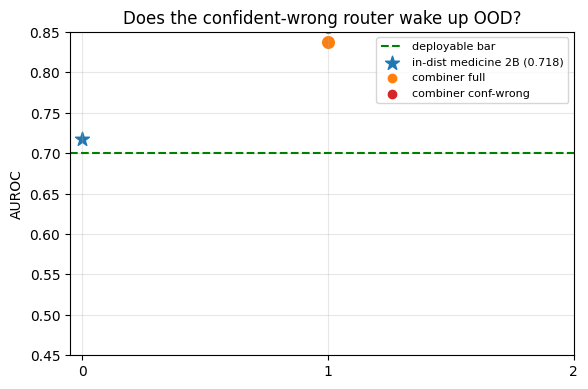


Decision: any bench with conf-wrong >=0.70 AND headroom -> the label-free router exists in the
shift regime; build the confident-error router there. If all stay <0.70, the negative now holds
across two regimes and the phenomenon paper is complete and airtight.


In [10]:
if RUN_GPU and PIVOT:
    ref=IN_DIST_REF; print("in-distribution reference (medicine 2B):", ref, "\n")
    for r in PIVOT:
        cw=r["combiner_conf_wrong"]; full=r["combiner_full"]; head=r["headroom"]
        d_cw = (cw-ref["combiner_conf_wrong"]) if not np.isnan(cw) else np.nan
        if head<0.08:
            v="DEAD OOD (no headroom to route)"
        elif not np.isnan(cw) and cw>=0.70 and full>=0.66:
            v="ROUTER LIVES OOD  <-- positive paper"
        elif not np.isnan(cw) and d_cw>=0.03:
            v="SIGNAL GROWS OOD (promising, sub-bar)"
        else:
            v="STILL BLIND OOD (phenomenon confirmed across regimes)"
        print(f"[{r['bench']:8s}] headroom={head:+.3f}  full={full:.3f}  conf-wrong={cw}  "
              f"(vs 0.718 ref: {d_cw:+.3f})  ->  {v}")
    # money plot
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(figsize=(6.5,4.2))
    ax.axhline(0.70,color="green",ls="--",label="deployable bar")
    ax.scatter([0],[ref["combiner_conf_wrong"]],s=110,marker="*",label="in-dist medicine 2B (0.718)")
    for j,r in enumerate(PIVOT,1):
        ax.scatter([j],[r["combiner_full"]],s=70,color="tab:orange")
        ax.scatter([j],[r["combiner_conf_wrong"]],s=90,color="tab:red")
        ax.annotate(r["bench"],(j,r["combiner_conf_wrong"]),fontsize=8,ha="center",va="bottom")
    ax.scatter([],[],color="tab:orange",label="combiner full"); ax.scatter([],[],color="tab:red",label="combiner conf-wrong")
    ax.set_xticks(range(len(PIVOT)+1)); ax.set_ylabel("AUROC"); ax.set_ylim(0.45,0.85)
    ax.set_title("Does the confident-wrong router wake up OOD?"); ax.legend(fontsize=8); ax.grid(alpha=.3); plt.show()
    print("\nDecision: any bench with conf-wrong >=0.70 AND headroom -> the label-free router exists in the")
    print("shift regime; build the confident-error router there. If all stay <0.70, the negative now holds")
    print("across two regimes and the phenomenon paper is complete and airtight.")
else:
    print("run on a GPU box (RUN_GPU=True) to populate the verdict.")